In [2]:
import sys
sys.path.append("../..")

# Load wildsat data

In [5]:
from pathlib import Path
from align_datasets.wildsat import WildSatTextDataset

train_dataset = WildSatTextDataset(
    split="train",
    wildsat_csv_path=Path("../../../../data/wildsat/geolocated_text_distribution_habitat_only.csv"),
    output_dir=Path("../../../../data/wildsat"),
    test_size=0.1,
    random_state=42,
)

[WildSatTextDataset.__init__] split=train csv_path=None wildsat_csv_path=PosixPath('../../../../data/wildsat/geolocated_text_distribution_habitat_only.csv') output_dir=PosixPath('../../../../data/wildsat') test_size=0.1 random_state=42
[WildSatTextDataset.__init__] creating splits from raw CSV: ../../../../data/wildsat/geolocated_text_distribution_habitat_only.csv → output_dir=../../../../data/wildsat
[WildSatTextDataset.load_wildsat_csv] reading ../../../../data/wildsat/geolocated_text_distribution_habitat_only.csv
[WildSatTextDataset.load_wildsat_csv] raw rows=2,513, columns=['taxon_id', 'species_name', 'section_name', 'section_type', 'text', 'lat', 'lon']
[WildSatTextDataset.create_splits_from_wildsat_csv] rows after validation=2,513, output_dir=../../../../data/wildsat
[WildSatTextDataset.__init__] loading split CSV: ../../../../data/wildsat/train.csv
[WildSatTextDataset.__init__] loaded 2,261 rows from train.csv


In [6]:
train_dataset.df

,lon,text,lat
0,153.596937,The Australian magpie is found in the Trans-Fl...,-31.573803
1,-117.881645,"The American crow has a large range, extending...",42.501572
2,-9.090520,The southern gatekeeper likes hot localities a...,38.638302
3,151.262902,George Caley reported that it was not common a...,-33.589081
4,-109.380356,The species is commonly found in moist canyons...,33.171963
...,...,...,...
2256,12.439771,The native range of Pinus halepensis extends f...,-3.054196
2257,-70.657320,Prionotus carolinus is found in shallow seas o...,41.545456
2258,-118.659566,This species is found throughout the western U...,34.108624
2259,105.841715,It is widespread in tropical and warm temperat...,-6.199383


In [7]:
len(train_dataset)

2261

In [8]:
train_dataset[3]

{'lat': np.float64(-33.58908103553333),
 'lon': np.float64(151.26290171873333),
 'text': 'George Caley reported that it was not common around Sydney even in early settlement days. Spotted pardalote numbers appear to be declining, especially in urban areas, but the species is not considered endangered at this time.'}

# See DataLoader

In [9]:
from dataset import LocationDescriptionDataModule

In [16]:
dm = LocationDescriptionDataModule(
    data_path="wildsat",
    dataset_name="WildSat-Text",
    batch_size=8,
    num_workers=0,  # easier debugging
    source_csv_path="../../../../data/wildsat/geolocated_text_distribution_habitat_only.csv",
    test_size=0.1,
    random_state=42,
)

In [17]:
dm.prepare_data()
dm.setup("fit")
train_loader = dm.train_dataloader()

[LocationDescriptionDataModule._ensure_splits_exist] Found existing splits: train=/media/volume/xAi-data/data/wildsat/train.csv, val=/media/volume/xAi-data/data/wildsat/val.csv
[LocationDescriptionDataModule.prepare_data] Reading train split from /media/volume/xAi-data/data/wildsat/train.csv


In [18]:
locations, texts = next(iter(train_loader))
print(locations.shape)   # [B, 2] -> [lat, lon]
print(type(texts), len(texts))
print(texts[0][:300])

torch.Size([8, 2])
<class 'tuple'> 8
Stellaria media is widespread in Asia, Europe, North America, and other parts of the world. There are several closely related plants referred to as chickweed, but which lack the culinary properties of plants in the genus Stellaria. Stellaria media is common in lawns, meadows, waste places, and open 


# Plot distribution of WildSAT data

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Plot distribution of WildSAT data

In [20]:
df = train_dataset.df

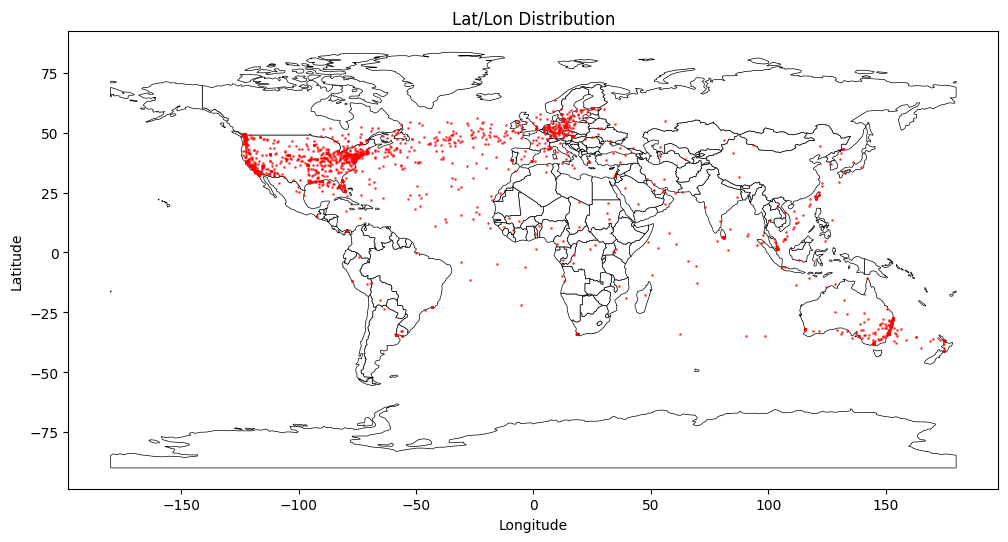

In [22]:
gdf_points = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs="EPSG:4326"
)

world = gpd.read_file("../../../../data/shapefiles/ne_110m_admin_0_countries.shp")
world = world.to_crs(gdf_points.crs)

fig, ax = plt.subplots(figsize=(12, 6))

world.plot(
    ax=ax,
    facecolor="white",
    edgecolor="black",
    linewidth=0.5
)

gdf_points.plot(
    ax=ax,
    markersize=1,
    color="red",   # or "black" if you want fully monochrome
    alpha=0.6
)

ax.set_title("Lat/Lon Distribution")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

# Sanity Check

In [34]:
import pandas as pd

In [35]:
all_df = pd.read_csv("../../../../data/wildsat/geolocated_text_distribution_habitat_only.csv")
all_df.head()

,taxon_id,species_name,section_name,section_type,text,lat,lon
0,7,Aramus guarauna,Distribution and habitat,range,The limpkin occurs from peninsular Florida (an...,-34.560130,-58.431756
1,162,Porzana carolina,Distribution and habitat,range,"The sora is common across North America, natur...",35.974430,-111.369743
2,199,Amaurornis phoenicurus,Distribution and habitat,range,Their breeding habitat is marshes across tropi...,2.524504,103.571547
3,288,Rallina fasciata,Distribution and habitat,range,"Found in far north-eastern India, eastern Bang...",1.331833,103.809159
4,329,Laterallus melanophaius,Distribution and habitat,range,The nominate subspecies of rufous-sided crake ...,-34.539619,-58.444027


In [38]:
test = all_df[
    (all_df['lon'] > -53) &
    (all_df['lon'] < -22) &
    (all_df['lat'] > 15) &
    (all_df['lat'] < 35)
]

In [39]:
test.head()

,taxon_id,species_name,section_name,section_type,text,lat,lon
475,14593,Pycnonotus cafer,Distribution and habitat,range,"This is a bird of dry scrub, open forest, plai...",27.947534,-35.013386
694,44575,Rattus rattus,Distribution and habitat,range,The black rat originated in India and Southeas...,27.740180,-49.427413
849,50868,Quercus suber,Distribution and habitat,range,The cork oak occupies the area around the west...,23.976503,-48.808145
896,52135,Amanita phalloides,Distribution and habitat,range,"The death cap is native to Europe, where it is...",19.586470,-48.108175
1117,56739,Ricinus communis,Distribution and habitat,range,Although R. communis is indigenous to the sout...,16.809871,-24.587721


In [49]:
test.iloc[2]['text']

'The cork oak occupies the area around the western Mediterranean basin. In Portugal, natural and cultivated stands cover an area of 750,000 hectares. There are natural populations of the nominate form at altitudes between 150 and 300 m (490 and 980 ft) above sea level, the subspecies occidentalis is found along the Atlantic coast. In Spain the occurrences remain mostly below 600 m (2,000 ft), but rarely reach heights of 1,200 m (3,900 ft). In Spain, cork oaks are common in the southern half of the country, as well as in the western and northeastern areas, but rare in central Spain. In Italy one finds natural occurrences along the Tyrrhenian Sea and in eastern Apulia on the Adriatic Sea. Also on the Adriatic is the cork oak on the Dalmatian coast. It is one of the most common forest trees in Sardinia. Natural and man-made occurrences exist in Africa on the Mediterranean coast of Tunisia, Algeria and Morocco and at altitudes up to 1,000 m (3,300 ft), on the High Atlas up to 2,000 m (6,60

In [40]:
sample = test.iloc[[0, 1, 2]].copy()

In [46]:
taxon_ids = sample["taxon_id"].tolist()

In [47]:
sys.path.append("../../0_text-descriptions-wildsat/wildsat-dataset-api")
from fetch_wiki_species_text import *

In [45]:
results = []

for i, row in sample.iterrows():
    name = row["species_name"]
    orig_lat, orig_lon = row["lat"], row["lon"]

    try:
        sections = get_sections_parse_api(name)
        print(sections)

        results.append({
            "species": name,
            "orig_lat": orig_lat,
            "orig_lon": orig_lon,
            "num_sections": len(sections),
            "has_range_section": any(s["section_type"] == "range" for s in sections),
            "has_habitat_section": any(s["section_type"] == "habitat" for s in sections),
        })

    except Exception as e:
        results.append({
            "species": name,
            "orig_lat": orig_lat,
            "orig_lon": orig_lon,
            "error": str(e)
        })

df_results = pd.DataFrame(results)
print(df_results)

[]
[]
[{'section_index': 0, 'section_name': 'Lead', 'section_type': 'lead', 'text': '</ref> | synonyms_ref = <ref> </ref> | synonyms = }} Quercus suber, commonly called the cork oak, is closely related to Greek word syphar meaning \'wrinkled skin\'.<ref> The Real Dirt |url=https://ucanr.edu/blog/real-dirt/article/local-trees-cork-oak |access-date=2026-03-23 |website=ucanr.edu |language=en}}</ref> It is a medium-sized, evergreen oak tree in the section Quercus sect. Cerris. It is the primary source of cork for wine bottle stoppers and other uses, such as cork flooring and as the cores of cricket balls. It is native to southwest Europe and northwest Africa. In the Mediterranean basin the tree is an ancient species with fossil remnants dating back to the Tertiary period.<ref> </ref> It can survive for as long as two centuries. Typically, once it reaches 25 years old, its thick bark can be harvested for cork every 9 to 12 years without causing harm to the tree.<ref> </ref> It endures droug

Something weird is happening... these lat lon are in the ocean. Maybe why this is being deprecated...

In [48]:
import requests
import time
from tqdm import tqdm

# reuse your existing functions:
# - get_sections_parse_api
# - lookup_name_inat_api

SESSION = requests.Session()

# -----------------------------
# Select rows
# -----------------------------
sample = test.iloc[[0, 1, 2]].copy()

# cache for iNat names
inat_cache = {}

results = []

# -----------------------------
# Loop (same logic as your main)
# -----------------------------
for _, row in tqdm(sample.iterrows(), total=len(sample)):
    tid = int(row["taxon_id"])
    lat = float(row["lat"])
    lon = float(row["lon"])

    # --- get species name via iNat API ---
    name = lookup_name_inat_api(tid, SESSION, inat_cache, delay=1.0)

    if not name:
        print(f"{tid}: NO NAME")
        continue

    print(f"\n{tid}  {name}")
    print(f"Original: ({lat:.2f}, {lon:.2f})")

    # --- fetch wikipedia sections ---
    try:
        sections = get_sections_parse_api(name)
    except Exception as e:
        print(f"  ERROR: {e}")
        continue

    if not sections:
        print("  No sections found")
        continue

    # --- summarize ---
    sec_types = sorted({s["section_type"] for s in sections})
    print(f"  Sections: {len(sections)} [{', '.join(sec_types)}]")

    # --- print range text (what you care about) ---
    for s in sections:
        if s["section_type"] == "range":
            print("\n  RANGE TEXT:")
            print(" ", s["text"][:500])  # truncate

    # store result
    results.append({
        "taxon_id": tid,
        "species_name": name,
        "lat": lat,
        "lon": lon,
        "num_sections": len(sections),
        "has_range": any(s["section_type"] == "range" for s in sections),
    })

    time.sleep(1.0)  # be nice to API

# -----------------------------
# Optional: dataframe summary
# -----------------------------
import pandas as pd
df_results = pd.DataFrame(results)
print("\nSummary:")
print(df_results)

  0%|          | 0/3 [00:00<?, ?it/s]


14593  Pycnonotus cafer
Original: (27.95, -35.01)


 33%|███▎      | 1/3 [00:02<00:04,  2.15s/it]

  No sections found

44575  Rattus rattus
Original: (27.74, -49.43)


 67%|██████▋   | 2/3 [00:05<00:02,  2.76s/it]

  No sections found

50868  Quercus suber
Original: (23.98, -48.81)
  Sections: 16 [habitat, lead, other, range]

  RANGE TEXT:
  thumb|Cork oak trees, near Roses, northeastern Spain The cork oak occupies the area around the western Mediterranean basin. In Portugal, natural and cultivated stands cover an area of 750,000 hectares.<ref name="page500" /><ref name="APCOR" /> There are natural populations of the nominate form at altitudes between above sea level, the subspecies occidentalis is found along the Atlantic coast. In Spain the occurrences remain mostly below , but rarely reach heights of . In Spain, cork oaks are com


100%|██████████| 3/3 [00:14<00:00,  4.74s/it]


Summary:
   taxon_id   species_name        lat        lon  num_sections  has_range
0     50868  Quercus suber  23.976503 -48.808145            16       True
